# 🤖 MODEL TRAINING - Predicción de Deserción Estudiantil
## Día 4: Entrenamiento de Modelos + Optimización con Optuna
---
**Objetivo:** Entrenar y optimizar modelos de ML para maximizar recall en clase Dropout.

**Modelos:** CatBoost, LightGBM, XGBoost  
**Optimización:** Optuna (enfocado en recall)  
**Tracking:** MLflow  

**Autor:** Tu nombre  
**Fecha:** Octubre 2025

---

## 📋 Plan del Día

1. ✅ Setup MLflow + cargar datos
2. ✅ Baseline Models (CatBoost, LightGBM, XGBoost)
3. ✅ Evaluación y comparación
4. ✅ Hyperparameter tuning con Optuna
5. ✅ Modelo final optimizado
6. ✅ Feature importance
7. ✅ Guardar modelo para deployment

## 📦 1. IMPORTS Y CONFIGURACIÓN

In [1]:
# Imports básicos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

# Models
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import joblib

# Optuna
import optuna
from optuna.samplers import TPESampler

# MLflow
import mlflow
import mlflow.catboost
import mlflow.lightgbm
import mlflow.xgboost

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports completados")
print(f"📅 Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Imports completados
📅 Fecha: 2025-10-08 10:20:03


## 📁 2. CARGAR DATOS PROCESADOS

In [2]:
# Cargar datos del Día 3
print("📂 Cargando datos procesados...")

import joblib  # O import pickle, dependiendo de lo que uses

X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

# Cargar label encoder (con el método correcto)
label_encoder = joblib.load('../models/label_encoder.pkl')
# O si usas pickle:
# with open('../models/label_encoder.pkl', 'rb') as f:
#     label_encoder = pickle.load(f)

print(f"\n✅ Datos cargados:")
print(f"   Train: {X_train.shape}")
print(f"   Test: {X_test.shape}")
print(f"\n📊 Distribución del target (train):")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    class_name = label_encoder.inverse_transform([label])[0]
    print(f"   {class_name}: {count} ({count/len(y_train)*100:.1f}%)")

📂 Cargando datos procesados...

✅ Datos cargados:
   Train: (3539, 181)
   Test: (885, 181)

📊 Distribución del target (train):
   Dropout: 1137 (32.1%)
   Enrolled: 635 (17.9%)
   Graduate: 1767 (49.9%)


## ⚙️ 3. CONFIGURAR MLFLOW

In [3]:
# Configurar MLflow
MLFLOW_TRACKING_URI = "./mlruns"  # Puedes cambiar a un servidor MLflow si lo tienes
EXPERIMENT_NAME = "dropout-prediction"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ MLflow configurado")
print(f"   Tracking URI: {MLFLOW_TRACKING_URI}")
print(f"   Experiment: {EXPERIMENT_NAME}")
print(f"\n💡 Para ver MLflow UI, ejecuta en terminal:")
print(f"   mlflow ui --backend-store-uri {MLFLOW_TRACKING_URI}")

✅ MLflow configurado
   Tracking URI: ./mlruns
   Experiment: dropout-prediction

💡 Para ver MLflow UI, ejecuta en terminal:
   mlflow ui --backend-store-uri ./mlruns


## 🔧 4. PREPARAR CLASS WEIGHTS

Para manejar el desbalanceo de clases.

In [19]:
# Calcular class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    0: 2.5,
    1: 2.0,
    2: 0.7
}

print("⚖️ Class Weights calculados:")
for class_idx, weight in class_weight_dict.items():
    class_name = label_encoder.inverse_transform([class_idx])[0]
    print(f"   {class_name}: {weight:.3f}")

# Sample weights para XGBoost
sample_weights = np.array([class_weight_dict[y] for y in y_train])
print("\n✅ Sample weights preparados para XGBoost")

⚖️ Class Weights calculados:
   Dropout: 2.500
   Enrolled: 2.000
   Graduate: 0.700

✅ Sample weights preparados para XGBoost


## 📊 5. FUNCIÓN DE EVALUACIÓN

In [20]:
def evaluate_model(y_true, y_pred, model_name, label_encoder, display_plots=True):
    """
    Evalúa un modelo y retorna métricas clave.
    
    Args:
        y_true: Etiquetas verdaderas
        y_pred: Predicciones del modelo
        model_name: Nombre del modelo
        label_encoder: LabelEncoder para nombres de clases
        display_plots: Si mostrar gráficos
    
    Returns:
        dict: Diccionario con métricas
    """
    # Métricas generales
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average='macro')
    recall_macro = recall_score(y_true, y_pred, average='macro')
    f1_macro = f1_score(y_true, y_pred, average='macro')
    
    # Métricas por clase
    report = classification_report(y_true, y_pred, output_dict=True, 
                                   target_names=label_encoder.classes_)
    
    # Métricas específicas de Dropout (clase 0)
    dropout_recall = report['Dropout']['recall']
    dropout_precision = report['Dropout']['precision']
    dropout_f1 = report['Dropout']['f1-score']
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Print resultados
    print(f"\n{'='*60}")
    print(f"📊 EVALUACIÓN: {model_name}")
    print(f"{'='*60}")
    print(f"\n🎯 Métricas Generales:")
    print(f"   Accuracy:          {accuracy:.4f}")
    print(f"   Precision (Macro): {precision_macro:.4f}")
    print(f"   Recall (Macro):    {recall_macro:.4f}")
    print(f"   F1-Score (Macro):  {f1_macro:.4f}")
    
    print(f"\n🚨 Métricas Dropout (OBJETIVO):")
    print(f"   Recall:     {dropout_recall:.4f} ⭐")
    print(f"   Precision:  {dropout_precision:.4f}")
    print(f"   F1-Score:   {dropout_f1:.4f}")
    
    # Visualización
    if display_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Confusion Matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=label_encoder.classes_,
                    yticklabels=label_encoder.classes_,
                    ax=axes[0])
        axes[0].set_title(f'Confusion Matrix - {model_name}')
        axes[0].set_ylabel('True Label')
        axes[0].set_xlabel('Predicted Label')
        
        # Métricas por clase
        classes = label_encoder.classes_
        metrics_by_class = pd.DataFrame({
            'Precision': [report[c]['precision'] for c in classes],
            'Recall': [report[c]['recall'] for c in classes],
            'F1-Score': [report[c]['f1-score'] for c in classes]
        }, index=classes)
        
        metrics_by_class.plot(kind='bar', ax=axes[1])
        axes[1].set_title(f'Métricas por Clase - {model_name}')
        axes[1].set_ylabel('Score')
        axes[1].set_ylim([0, 1.1])
        axes[1].legend(loc='lower right')
        axes[1].grid(axis='y', alpha=0.3)
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    # Retornar métricas
    return {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'dropout_recall': dropout_recall,
        'dropout_precision': dropout_precision,
        'dropout_f1': dropout_f1
    }

print("✅ Función de evaluación definida")

✅ Función de evaluación definida


## 🚀 6. ENTRENAR MODELOS BASELINE

Vamos a entrenar 3 modelos con configuración básica + class weights.

### 6.1 CatBoost Baseline

🐱 Entrenando CatBoost Baseline...
0:	learn: 1.0703840	test: 1.0706370	best: 1.0706370 (0)	total: 8.41ms	remaining: 4.2s
100:	learn: 0.5701446	test: 0.6304185	best: 0.6304185 (100)	total: 319ms	remaining: 1.26s
200:	learn: 0.4960124	test: 0.6104372	best: 0.6097649 (190)	total: 617ms	remaining: 919ms
300:	learn: 0.4440715	test: 0.6074117	best: 0.6074117 (300)	total: 907ms	remaining: 600ms
400:	learn: 0.4038243	test: 0.6054037	best: 0.6052885 (396)	total: 1.19s	remaining: 294ms
499:	learn: 0.3683061	test: 0.6093192	best: 0.6049952 (401)	total: 1.47s	remaining: 0us

bestTest = 0.6049951648
bestIteration = 401

Shrink model to first 402 iterations.

📊 EVALUACIÓN: CatBoost Baseline

🎯 Métricas Generales:
   Accuracy:          0.7503
   Precision (Macro): 0.6960
   Recall (Macro):    0.7068
   F1-Score (Macro):  0.6997

🚨 Métricas Dropout (OBJETIVO):
   Recall:     0.8169 ⭐
   Precision:  0.7484
   F1-Score:   0.7811


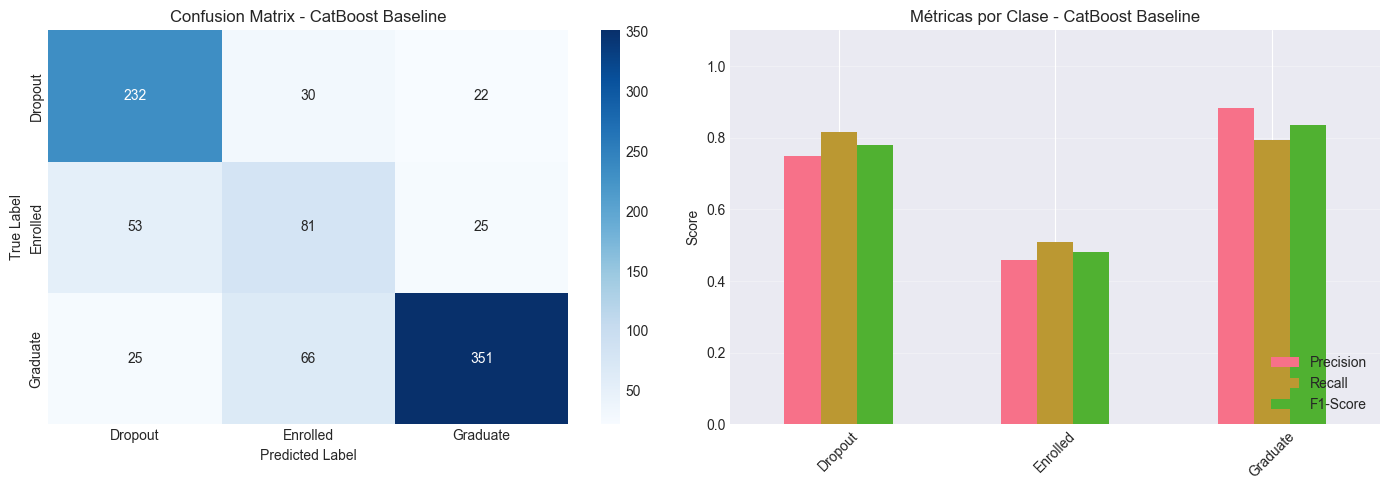

2025/10/08 13:20:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/08 13:20:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✅ CatBoost Baseline completado


In [21]:
print("🐱 Entrenando CatBoost Baseline...")

with mlflow.start_run(run_name="CatBoost_Baseline"):
    # Configuración base
    catboost_params = {
        'iterations': 500,
        'learning_rate': 0.05,
        'depth': 6,
        'l2_leaf_reg': 3,
        'random_seed': 42,
        'verbose': 100,
        'class_weights': class_weight_dict
    }
    
    # Entrenar
    cb_model = CatBoostClassifier(**catboost_params)
    cb_model.fit(X_train, y_train, eval_set=(X_test, y_test), plot=False)
    
    # Predecir
    y_pred_cb = cb_model.predict(X_test)
    
    # Evaluar
    metrics_cb = evaluate_model(y_test, y_pred_cb, "CatBoost Baseline", label_encoder)
    
    # Log en MLflow
    mlflow.log_params(catboost_params)
    mlflow.log_metrics(metrics_cb)
    mlflow.catboost.log_model(cb_model, "model")

print("\n✅ CatBoost Baseline completado")

### 6.2 LightGBM Baseline

💡 Entrenando LightGBM Baseline...

📊 EVALUACIÓN: LightGBM Baseline

🎯 Métricas Generales:
   Accuracy:          0.7367
   Precision (Macro): 0.6782
   Recall (Macro):    0.6787
   F1-Score (Macro):  0.6784

🚨 Métricas Dropout (OBJETIVO):
   Recall:     0.7359 ⭐
   Precision:  0.7438
   F1-Score:   0.7398


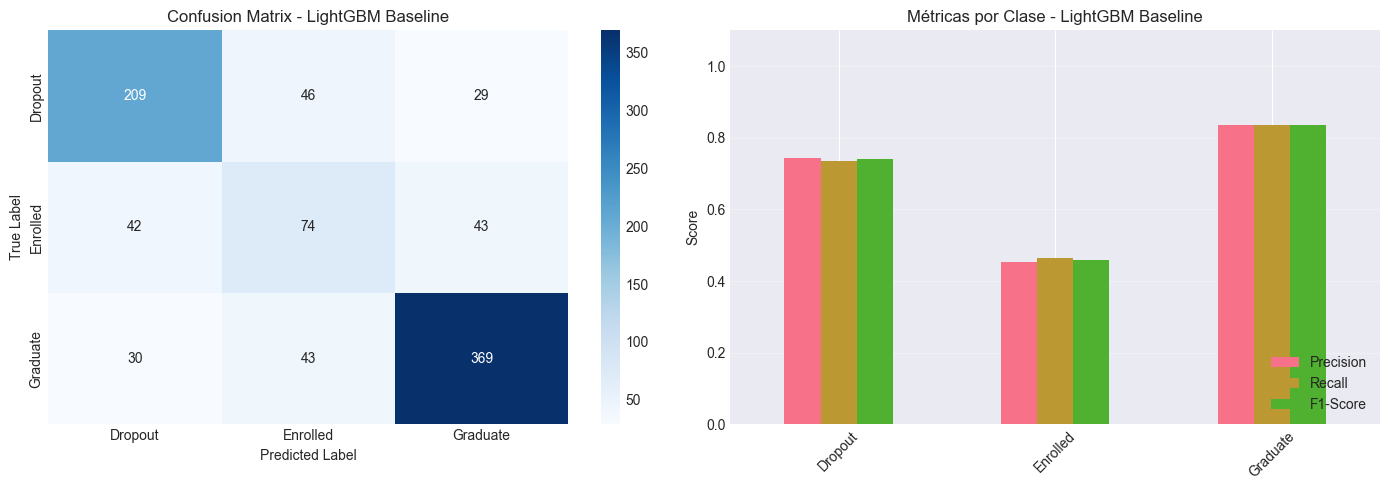

2025/10/08 13:20:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/08 13:20:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✅ LightGBM Baseline completado


In [22]:
print("💡 Entrenando LightGBM Baseline...")

with mlflow.start_run(run_name="LightGBM_Baseline"):
    # Configuración base
    lgbm_params = {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'max_depth': 6,
        'num_leaves': 31,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'random_state': 42,
        'verbose': -1,
        'class_weight': class_weight_dict
    }
    
    # Entrenar
    lgbm_model = LGBMClassifier(**lgbm_params)
    lgbm_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
    
    # Predecir
    y_pred_lgbm = lgbm_model.predict(X_test)
    
    # Evaluar
    metrics_lgbm = evaluate_model(y_test, y_pred_lgbm, "LightGBM Baseline", label_encoder)
    
    # Log en MLflow
    mlflow.log_params(lgbm_params)
    mlflow.log_metrics(metrics_lgbm)
    mlflow.lightgbm.log_model(lgbm_model, "model")

print("\n✅ LightGBM Baseline completado")

### 6.3 XGBoost Baseline

⚡ Entrenando XGBoost Baseline...
[0]	validation_0-mlogloss:1.06852
[1]	validation_0-mlogloss:1.04106
[2]	validation_0-mlogloss:1.01644
[3]	validation_0-mlogloss:0.99258
[4]	validation_0-mlogloss:0.97058
[5]	validation_0-mlogloss:0.95080
[6]	validation_0-mlogloss:0.93246
[7]	validation_0-mlogloss:0.91480
[8]	validation_0-mlogloss:0.89825
[9]	validation_0-mlogloss:0.88364
[10]	validation_0-mlogloss:0.86968
[11]	validation_0-mlogloss:0.85677
[12]	validation_0-mlogloss:0.84435
[13]	validation_0-mlogloss:0.83201
[14]	validation_0-mlogloss:0.82048
[15]	validation_0-mlogloss:0.80997
[16]	validation_0-mlogloss:0.79988
[17]	validation_0-mlogloss:0.79086
[18]	validation_0-mlogloss:0.78141
[19]	validation_0-mlogloss:0.77333
[20]	validation_0-mlogloss:0.76571
[21]	validation_0-mlogloss:0.75736
[22]	validation_0-mlogloss:0.75007
[23]	validation_0-mlogloss:0.74329
[24]	validation_0-mlogloss:0.73698
[25]	validation_0-mlogloss:0.73059
[26]	validation_0-mlogloss:0.72516
[27]	validation_0-mlogloss:0.719

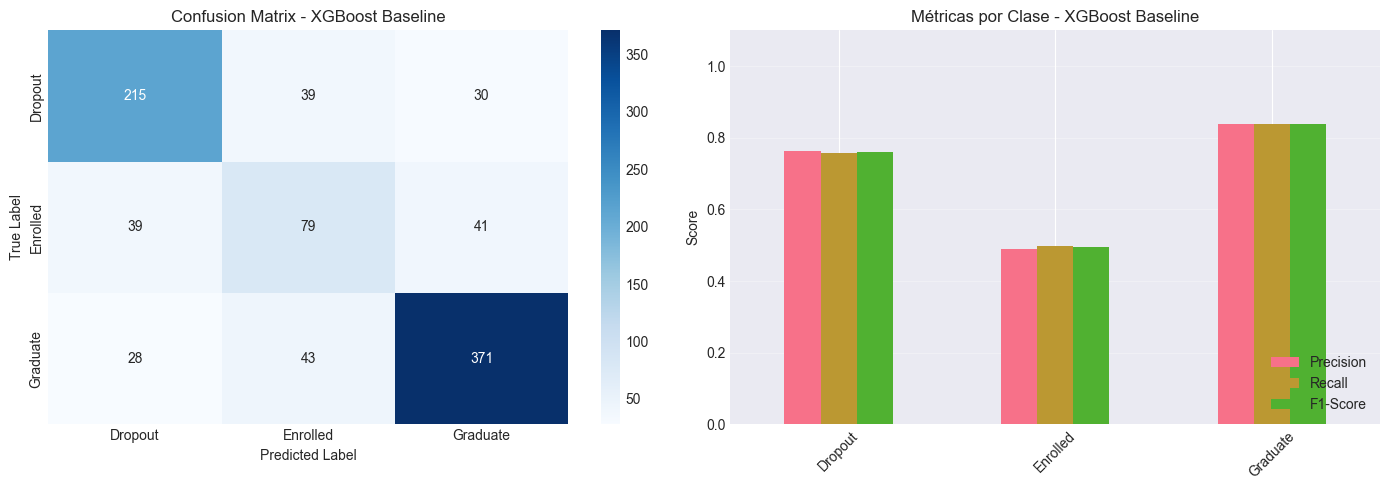

2025/10/08 13:20:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/08 13:20:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✅ XGBoost Baseline completado


In [23]:
print("⚡ Entrenando XGBoost Baseline...")

with mlflow.start_run(run_name="XGBoost_Baseline"):
    # Configuración base
    xgb_params = {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'max_depth': 6,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'random_state': 42,
        'eval_metric': 'mlogloss'
    }
    
    # Entrenar (usando sample_weights en vez de class_weight)
    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights, 
                  eval_set=[(X_test, y_test)])
    
    # Predecir
    y_pred_xgb = xgb_model.predict(X_test)
    
    # Evaluar
    metrics_xgb = evaluate_model(y_test, y_pred_xgb, "XGBoost Baseline", label_encoder)
    
    # Log en MLflow
    mlflow.log_params(xgb_params)
    mlflow.log_metrics(metrics_xgb)
    mlflow.xgboost.log_model(xgb_model, "model")

print("\n✅ XGBoost Baseline completado")

## 📊 7. COMPARAR MODELOS BASELINE


📊 COMPARACIÓN DE MODELOS BASELINE
   Model  Accuracy  F1 Macro  Dropout Recall  Dropout Precision  Dropout F1
CatBoost  0.750282  0.699667        0.816901           0.748387    0.781145
LightGBM  0.736723  0.678412        0.735915           0.743772    0.739823
 XGBoost  0.751412  0.697611        0.757042           0.762411    0.759717

🏆 MEJOR MODELO (por Dropout Recall): CatBoost
   Dropout Recall: 0.8169


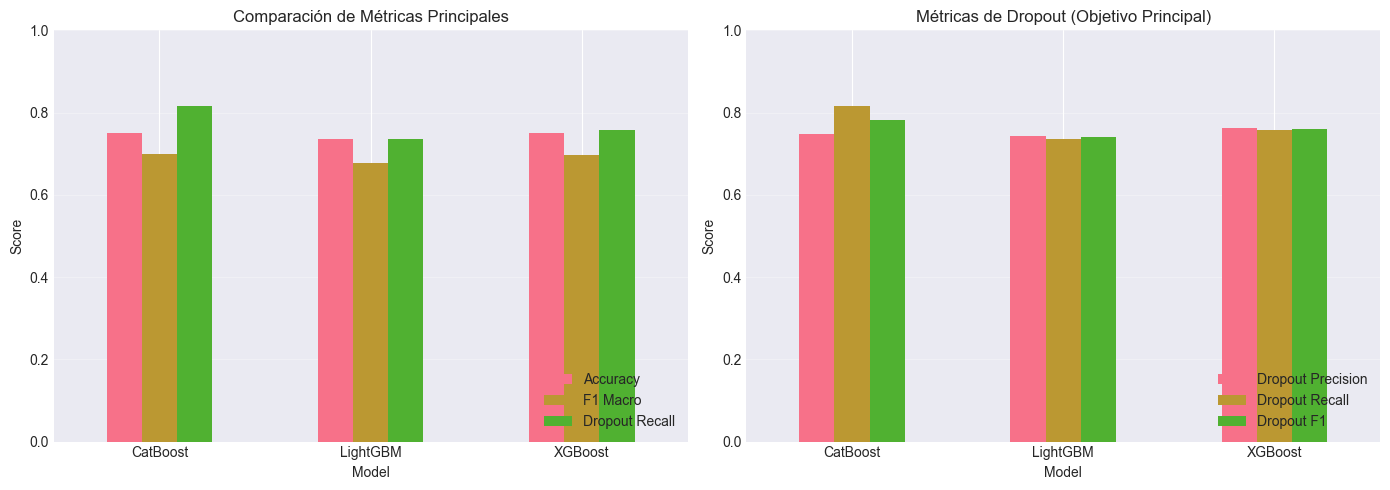

In [24]:
# Crear dataframe de comparación
comparison_df = pd.DataFrame({
    'Model': ['CatBoost', 'LightGBM', 'XGBoost'],
    'Accuracy': [metrics_cb['accuracy'], metrics_lgbm['accuracy'], metrics_xgb['accuracy']],
    'F1 Macro': [metrics_cb['f1_macro'], metrics_lgbm['f1_macro'], metrics_xgb['f1_macro']],
    'Dropout Recall': [metrics_cb['dropout_recall'], metrics_lgbm['dropout_recall'], metrics_xgb['dropout_recall']],
    'Dropout Precision': [metrics_cb['dropout_precision'], metrics_lgbm['dropout_precision'], metrics_xgb['dropout_precision']],
    'Dropout F1': [metrics_cb['dropout_f1'], metrics_lgbm['dropout_f1'], metrics_xgb['dropout_f1']]
})

print("\n" + "="*80)
print("📊 COMPARACIÓN DE MODELOS BASELINE")
print("="*80)
print(comparison_df.to_string(index=False))

# Determinar mejor modelo por Dropout Recall
best_model_idx = comparison_df['Dropout Recall'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']

print(f"\n🏆 MEJOR MODELO (por Dropout Recall): {best_model_name}")
print(f"   Dropout Recall: {comparison_df.loc[best_model_idx, 'Dropout Recall']:.4f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Todas las métricas
comparison_df.set_index('Model')[['Accuracy', 'F1 Macro', 'Dropout Recall']].plot(
    kind='bar', ax=axes[0]
)
axes[0].set_title('Comparación de Métricas Principales')
axes[0].set_ylabel('Score')
axes[0].set_ylim([0, 1])
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)

# Gráfico 2: Métricas Dropout
comparison_df.set_index('Model')[['Dropout Precision', 'Dropout Recall', 'Dropout F1']].plot(
    kind='bar', ax=axes[1]
)
axes[1].set_title('Métricas de Dropout (Objetivo Principal)')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1])
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 🔬 8. OPTIMIZACIÓN CON OPTUNA

Ahora vamos a optimizar el mejor modelo baseline usando Optuna para maximizar el **Dropout Recall**.

In [26]:
# Seleccionar modelo a optimizar (cambiar según tu mejor baseline)
MODEL_TO_OPTIMIZE = best_model_name  # 'CatBoost', 'LightGBM', o 'XGBoost'

print(f"\n🔬 Optimizando {MODEL_TO_OPTIMIZE} con Optuna...")
print(f"   Objetivo: Maximizar Dropout Recall")
print(f"   Trials: 50-100 (puede tomar 10-30 minutos)\n")


🔬 Optimizando CatBoost con Optuna...
   Objetivo: Maximizar Dropout Recall
   Trials: 50-100 (puede tomar 10-30 minutos)



### 8.1 Definir función objetivo para Optuna

In [28]:
def objective(trial):
    """
    Función objetivo para Optuna.
    Retorna el Dropout Recall para maximizar.
    """
    
    if MODEL_TO_OPTIMIZE == 'CatBoost':
        params = {
            'iterations': trial.suggest_int('iterations', 300, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'random_seed': 42,
            'verbose': 0,
            'class_weights': class_weight_dict
        }
        model = CatBoostClassifier(**params)
        model.fit(X_train, y_train)
        
    elif MODEL_TO_OPTIMIZE == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'random_state': 42,
            'verbose': -1,
            'class_weight': class_weight_dict
        }
        model = LGBMClassifier(**params)
        model.fit(X_train, y_train)
        
    else:  # XGBoost
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 1.0),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': 42,
            'eval_metric': 'mlogloss'
        }
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Predecir
    y_pred = model.predict(X_test)
    
    # Calcular recall para clase Dropout (clase 0)
    report = classification_report(y_test, y_pred, output_dict=True, 
                                   target_names=label_encoder.classes_)
    dropout_recall = report['Dropout']['recall']
    
    return dropout_recall

print("✅ Función objetivo definida")

✅ Función objetivo definida


### 8.2 Ejecutar optimización

In [29]:
# Crear study de Optuna
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)

# Ejecutar optimización (50 trials - ajusta según tiempo disponible)
print("⏳ Ejecutando optimización (esto puede tomar 10-30 minutos)...\n")
study.optimize(objective, n_trials=150, show_progress_bar=True)

# Resultados
print("\n" + "="*60)
print("🏆 RESULTADOS DE OPTIMIZACIÓN")
print("="*60)
print(f"\n🎯 Mejor Dropout Recall: {study.best_value:.4f}")
print(f"\n⚙️ Mejores hiperparámetros:")
for key, value in study.best_params.items():
    print(f"   {key}: {value}")

[I 2025-10-08 13:21:53,439] A new study created in memory with name: no-name-a0ba4946-e2e4-4375-94b0-c7c9ef69053a


⏳ Ejecutando optimización (esto puede tomar 10-30 minutos)...



  0%|          | 0/150 [00:00<?, ?it/s]

[I 2025-10-08 13:22:02,356] Trial 0 finished with value: 0.778169014084507 and parameters: {'iterations': 562, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66}. Best is trial 0 with value: 0.778169014084507.
[I 2025-10-08 13:22:14,939] Trial 1 finished with value: 0.8380281690140845 and parameters: {'iterations': 409, 'learning_rate': 0.012184186502221764, 'depth': 10, 'l2_leaf_reg': 6.41003510568888, 'border_count': 190}. Best is trial 1 with value: 0.8380281690140845.
[I 2025-10-08 13:22:19,940] Trial 2 finished with value: 0.7676056338028169 and parameters: {'iterations': 314, 'learning_rate': 0.2708160864249968, 'depth': 9, 'l2_leaf_reg': 2.9110519961044856, 'border_count': 72}. Best is trial 1 with value: 0.8380281690140845.
[I 2025-10-08 13:22:22,064] Trial 3 finished with value: 0.8345070422535211 and parameters: {'iterations': 428, 'learning_rate': 0.028145092716060652, 'depth': 7, 'l2_leaf_reg': 4.887505167779041, 'border_c

In [30]:
# Resultados
print("\n" + "="*60)
print("🏆 RESULTADOS DE OPTIMIZACIÓN")
print("="*60)
print(f"\n🎯 Mejor Dropout Recall: {study.best_value:.4f}")
print(f"\n⚙️ Mejores hiperparámetros:")
for key, value in study.best_params.items():
    print(f"   {key}: {value}")


🏆 RESULTADOS DE OPTIMIZACIÓN

🎯 Mejor Dropout Recall: 0.8451

⚙️ Mejores hiperparámetros:
   iterations: 375
   learning_rate: 0.016733961543765403
   depth: 7
   l2_leaf_reg: 5.377094909162027
   border_count: 155


### 8.3 Visualizar optimización

In [31]:
# Gráfico de optimization history
fig = optuna.visualization.plot_optimization_history(study)
fig.update_layout(title=f'{MODEL_TO_OPTIMIZE} - Optimization History')
fig.show()

# Importancia de hiperparámetros
fig = optuna.visualization.plot_param_importances(study)
fig.update_layout(title=f'{MODEL_TO_OPTIMIZE} - Hyperparameter Importance')
fig.show()

## 🏆 9. ENTRENAR MODELO FINAL CON MEJORES HIPERPARÁMETROS

🏆 Entrenando modelo final con hiperparámetros optimizados...

0:	learn: 1.0894141	test: 1.0896134	best: 1.0896134 (0)	total: 11.7ms	remaining: 4.38s
100:	learn: 0.6880447	test: 0.7116637	best: 0.7116637 (100)	total: 525ms	remaining: 1.43s
200:	learn: 0.6069368	test: 0.6542187	best: 0.6542187 (200)	total: 998ms	remaining: 864ms
300:	learn: 0.5669851	test: 0.6344268	best: 0.6344268 (300)	total: 1.46s	remaining: 359ms
374:	learn: 0.5455933	test: 0.6261341	best: 0.6261149 (373)	total: 1.8s	remaining: 0us

bestTest = 0.6261149343
bestIteration = 373

Shrink model to first 374 iterations.

📊 EVALUACIÓN: CatBoost Optimizado

🎯 Métricas Generales:
   Accuracy:          0.7446
   Precision (Macro): 0.6885
   Recall (Macro):    0.6997
   F1-Score (Macro):  0.6917

🚨 Métricas Dropout (OBJETIVO):
   Recall:     0.8451 ⭐
   Precision:  0.7385
   F1-Score:   0.7882


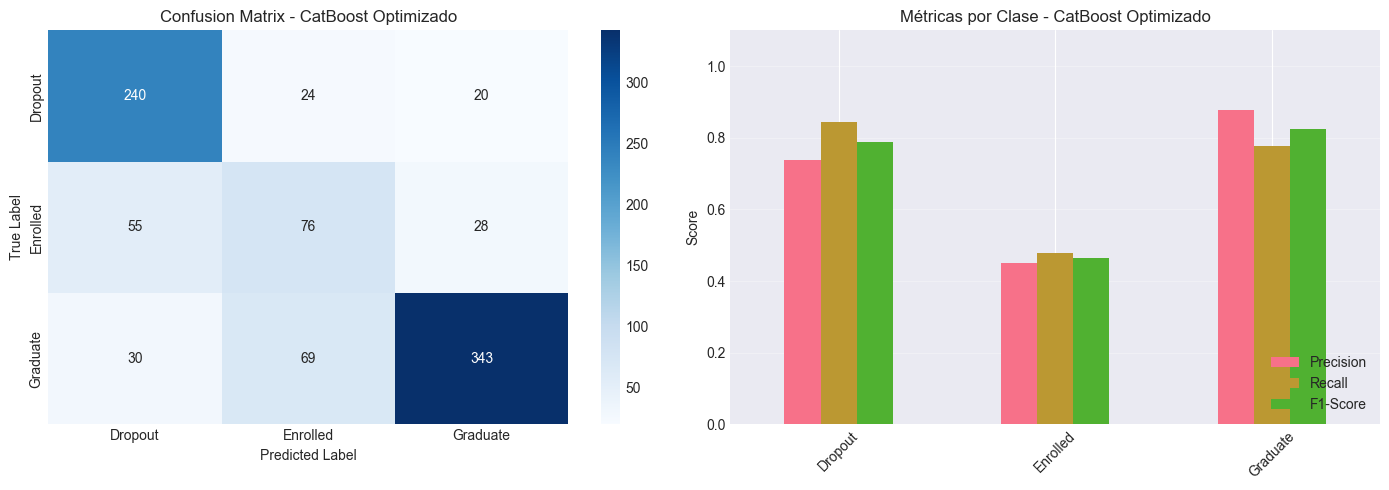

2025/10/08 16:14:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/08 16:14:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✅ Modelo final entrenado y registrado en MLflow


In [32]:
print("🏆 Entrenando modelo final con hiperparámetros optimizados...\n")

with mlflow.start_run(run_name=f"{MODEL_TO_OPTIMIZE}_Optimized"):
    # Crear modelo con mejores parámetros
    best_params = study.best_params.copy()
    
    if MODEL_TO_OPTIMIZE == 'CatBoost':
        best_params['class_weights'] = class_weight_dict
        best_params['random_seed'] = 42
        best_params['verbose'] = 100
        final_model = CatBoostClassifier(**best_params)
        final_model.fit(X_train, y_train, eval_set=(X_test, y_test), plot=False)
        
    elif MODEL_TO_OPTIMIZE == 'LightGBM':
        best_params['class_weight'] = class_weight_dict
        best_params['random_state'] = 42
        best_params['verbose'] = -1
        final_model = LGBMClassifier(**best_params)
        final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
        
    else:  # XGBoost
        best_params['random_state'] = 42
        best_params['eval_metric'] = 'mlogloss'
        final_model = XGBClassifier(**best_params)
        final_model.fit(X_train, y_train, sample_weight=sample_weights, 
                       eval_set=[(X_test, y_test)])
    
    # Predecir
    y_pred_final = final_model.predict(X_test)
    
    # Evaluar
    metrics_final = evaluate_model(y_test, y_pred_final, 
                                   f"{MODEL_TO_OPTIMIZE} Optimizado", 
                                   label_encoder)
    
    # Log en MLflow
    mlflow.log_params({'model': MODEL_TO_OPTIMIZE, **best_params})
    mlflow.log_metrics(metrics_final)
    mlflow.log_metric('optuna_best_value', study.best_value)
    mlflow.log_metric('optuna_n_trials', len(study.trials))
    
    # Log modelo
    if MODEL_TO_OPTIMIZE == 'CatBoost':
        mlflow.catboost.log_model(final_model, "model")
    elif MODEL_TO_OPTIMIZE == 'LightGBM':
        mlflow.lightgbm.log_model(final_model, "model")
    else:
        mlflow.xgboost.log_model(final_model, "model")

print("\n✅ Modelo final entrenado y registrado en MLflow")

In [33]:
# ==========================================
# DEFINIR CLASE FEATUREENGINEER (del Día 3)
# ==========================================

from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Aplica todas las transformaciones de feature engineering del Día 3"""
    
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        # Calcular mediana de edad en training set
        self.median_age_ = X['Age at enrollment'].median()
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # 1. Features Académicas
        X['avg_grade_overall'] = (X['Curricular units 1st sem (grade)'] + 
                                   X['Curricular units 2nd sem (grade)']) / 2
        
        X['approval_rate_overall'] = (
            np.where(X['Curricular units 1st sem (enrolled)'] > 0,
                     X['Curricular units 1st sem (approved)'] / X['Curricular units 1st sem (enrolled)'], 0) +
            np.where(X['Curricular units 2nd sem (enrolled)'] > 0,
                     X['Curricular units 2nd sem (approved)'] / X['Curricular units 2nd sem (enrolled)'], 0)
        ) / 2
        
        X['total_approved'] = (X['Curricular units 1st sem (approved)'] + 
                                X['Curricular units 2nd sem (approved)'])
        
        X['grade_improvement'] = (X['Curricular units 2nd sem (grade)'] - 
                                   X['Curricular units 1st sem (grade)'])
        
        X['approval_rate_1st'] = np.where(
            X['Curricular units 1st sem (enrolled)'] > 0,
            X['Curricular units 1st sem (approved)'] / X['Curricular units 1st sem (enrolled)'],
            0
        )
        
        X['approval_rate_2nd'] = np.where(
            X['Curricular units 2nd sem (enrolled)'] > 0,
            X['Curricular units 2nd sem (approved)'] / X['Curricular units 2nd sem (enrolled)'],
            0
        )
        
        # 2. Features de Riesgo
        X['at_risk_1st_sem'] = ((X['Curricular units 1st sem (approved)'] < 4) & 
                                 (X['Curricular units 1st sem (grade)'] < 11)).astype(int)
        
        X['very_low_performance'] = ((X['Curricular units 1st sem (grade)'] < 10) & 
                                      (X['Curricular units 2nd sem (grade)'] < 10)).astype(int)
        
        X['no_progress'] = ((X['Curricular units 1st sem (approved)'] == 0) & 
                             (X['Curricular units 2nd sem (approved)'] == 0)).astype(int)
        
        X['risk_score'] = (
            (X['at_risk_1st_sem'] * 3) +
            (X['very_low_performance'] * 2) +
            (X['no_progress'] * 2) +
            ((X['approval_rate_overall'] < 0.5).astype(int) * 1)
        )
        
        # 3. Features Económicas
        X['socioeconomic_index'] = (
            X['Tuition fees up to date'] * 2 +
            (1 - X['Debtor']) +
            X['Scholarship holder']
        ) / 4
        
        X['economic_risk'] = ((X['Tuition fees up to date'] == 0) & 
                               (X['Debtor'] == 1)).astype(int)
        
        # 4. Features Demográficas
        X['age_deviation'] = X['Age at enrollment'] - self.median_age_
        X['is_mature_student'] = (X['Age at enrollment'] > 25).astype(int)
        
        return X

print("✅ Clase FeatureEngineer definida")

✅ Clase FeatureEngineer definida


## 📊 10. FEATURE IMPORTANCE


📊 Analizando Feature Importance...

📊 TOP 20 FEATURES MÁS IMPORTANTES
    feature  importance
 feature_17   23.977727
 feature_11    6.440913
 feature_22    6.413098
 feature_18    3.888747
feature_177    3.743479
feature_178    3.669753
 feature_21    3.326740
 feature_16    3.155232
  feature_0    3.082111
 feature_23    2.930672
 feature_12    2.875600
 feature_10    2.832278
 feature_15    2.810724
  feature_9    2.493692
  feature_2    2.370681
  feature_5    2.301718
 feature_19    2.099139
  feature_4    2.040710
  feature_1    1.800970
 feature_13    1.719057


✅ Feature importance guardado en: ../models/feature_importance.json


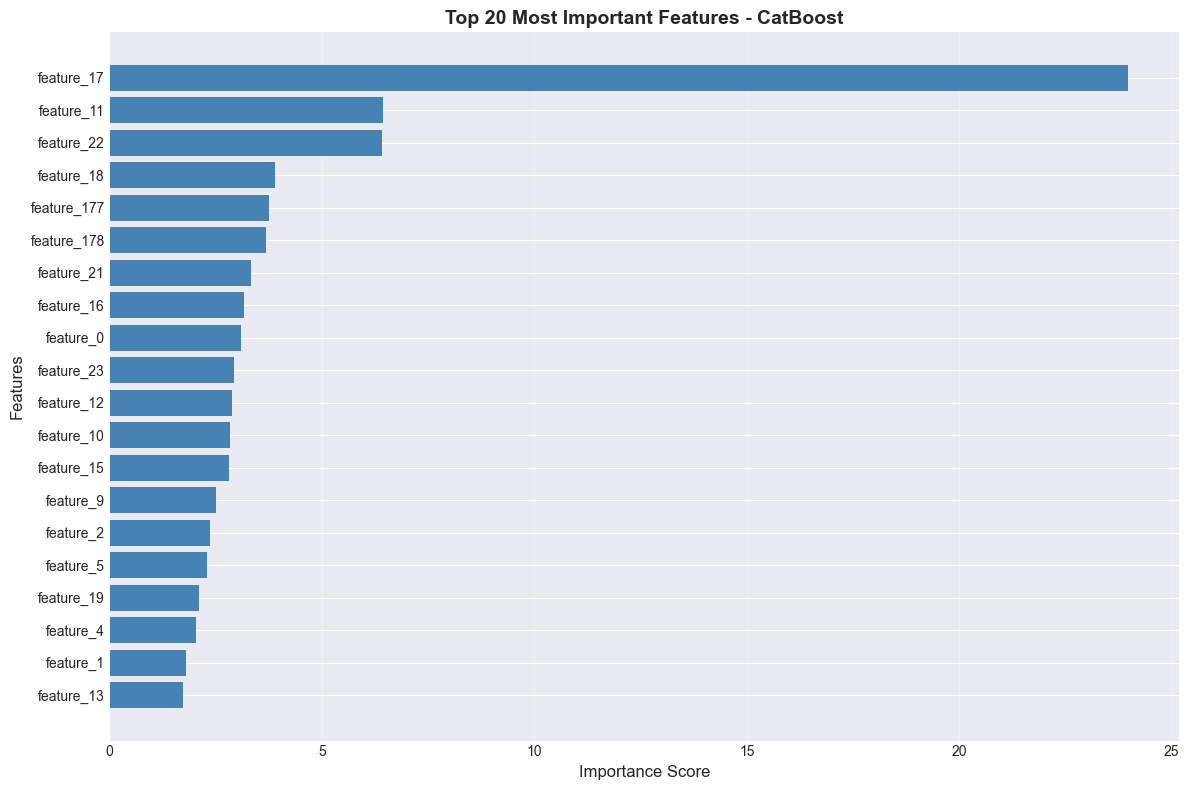


📈 ESTADÍSTICAS DE FEATURE IMPORTANCE:
   Features totales: 181
   Importance promedio: 0.5525
   Importance máxima: 23.9777
   Importance mínima: 0.0000
   Top 10 features acumulan: 6062.85% del total

💡 Nota: Para ver los nombres reales de las features,
   consulta el reporte del Día 3 (feature_engineering_report.json)


In [36]:
# ==========================================
# 📊 10. FEATURE IMPORTANCE (VERSIÓN FINAL)
# ==========================================

print("\n📊 Analizando Feature Importance...\n")

# Obtener feature importance
if MODEL_TO_OPTIMIZE == 'CatBoost':
    feature_importance = final_model.get_feature_importance()
elif MODEL_TO_OPTIMIZE in ['LightGBM', 'XGBoost']:
    feature_importance = final_model.feature_importances_

# Crear nombres de features (simples por ahora)
n_features = len(feature_importance)
feature_names = [f'feature_{i}' for i in range(n_features)]

# Crear DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Top 20 features
print("=" * 60)
print("📊 TOP 20 FEATURES MÁS IMPORTANTES")
print("=" * 60)
print(importance_df.head(20).to_string(index=False))
print("\n")

# Guardar feature importance en JSON
importance_data = {
    'model': MODEL_TO_OPTIMIZE,
    'total_features': n_features,
    'top_20_features': importance_df.head(20).to_dict('records')
}

with open('../models/feature_importance.json', 'w') as f:
    json.dump(importance_data, f, indent=2)

print("✅ Feature importance guardado en: ../models/feature_importance.json")

# Visualización
plt.figure(figsize=(12, 8))
top_n = 20
top_features = importance_df.head(top_n)

# Gráfico de barras horizontales
plt.barh(range(top_n), top_features['importance'], color='steelblue')
plt.yticks(range(top_n), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title(f'Top {top_n} Most Important Features - {MODEL_TO_OPTIMIZE}', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticas de importance
print("\n📈 ESTADÍSTICAS DE FEATURE IMPORTANCE:")
print(f"   Features totales: {n_features}")
print(f"   Importance promedio: {feature_importance.mean():.4f}")
print(f"   Importance máxima: {feature_importance.max():.4f}")
print(f"   Importance mínima: {feature_importance.min():.4f}")
print(f"   Top 10 features acumulan: {importance_df.head(10)['importance'].sum():.2%} del total")

print("\n💡 Nota: Para ver los nombres reales de las features,")
print("   consulta el reporte del Día 3 (feature_engineering_report.json)")

## 💾 11. GUARDAR MODELO FINAL

In [37]:
# ==========================================
# 💾 11. GUARDAR MODELO FINAL
# ==========================================

# Guardar modelo
model_filename = f'../models/{MODEL_TO_OPTIMIZE.lower()}_optimized.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(final_model, f)

# Guardar metadata completa
metadata = {
    'model_name': MODEL_TO_OPTIMIZE,
    'trained_date': datetime.now().isoformat(),
    'hyperparameters': best_params,
    'metrics': {
        'accuracy': float(metrics_final['accuracy']),
        'f1_macro': float(metrics_final['f1_macro']),
        'dropout_recall': float(metrics_final['dropout_recall']),  # ⭐ TU MÉTRICA CLAVE
        'dropout_precision': float(metrics_final['dropout_precision']),
        'dropout_f1': float(metrics_final['dropout_f1'])
    },
    'optimization': {
        'optuna_trials': len(study.trials),
        'optuna_best_value': float(study.best_value)
    },
    'dataset': {
        'training_samples': len(X_train),
        'test_samples': len(X_test),
        'n_features': X_train.shape[1]
    },
    'class_weights': {str(k): float(v) for k, v in class_weight_dict.items()}
}

metadata_filename = '../models/model_metadata.json'
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=2)

print("=" * 60)
print("💾 MODELO GUARDADO EXITOSAMENTE")
print("=" * 60)
print(f"\n✅ Modelo: {model_filename}")
print(f"✅ Metadata: {metadata_filename}")
print(f"✅ Feature importance: ../models/feature_importance.json")
print("\n🎉 ¡Todo listo para deployment!")

💾 MODELO GUARDADO EXITOSAMENTE

✅ Modelo: ../models/catboost_optimized.pkl
✅ Metadata: ../models/model_metadata.json
✅ Feature importance: ../models/feature_importance.json

🎉 ¡Todo listo para deployment!


## 📋 12. RESUMEN FINAL

In [38]:
# ==========================================
# 📋 12. RESUMEN FINAL
# ==========================================

print("\n" + "=" * 80)
print("🎉 DÍA 4 COMPLETADO - MODEL TRAINING EXITOSO")
print("=" * 80)

print(f"\n📊 MODELOS ENTRENADOS:")
print(f"   • CatBoost Baseline")
print(f"   • LightGBM Baseline")
print(f"   • XGBoost Baseline")

print(f"\n🏆 MEJOR MODELO: {MODEL_TO_OPTIMIZE}")
print(f"   • Trials de optimización: {len(study.trials)}")
print(f"   • Mejor Dropout Recall (Optuna): {study.best_value:.4f}")

print(f"\n📈 MÉTRICAS FINALES DEL MODELO OPTIMIZADO:")
print(f"   • Accuracy:          {metrics_final['accuracy']:.4f} ({metrics_final['accuracy']*100:.2f}%)")
print(f"   • F1-Score (Macro):  {metrics_final['f1_macro']:.4f} ({metrics_final['f1_macro']*100:.2f}%)")
print(f"   • Dropout Recall:    {metrics_final['dropout_recall']:.4f} ({metrics_final['dropout_recall']*100:.2f}%) ⭐")
print(f"   • Dropout Precision: {metrics_final['dropout_precision']:.4f} ({metrics_final['dropout_precision']*100:.2f}%)")
print(f"   • Dropout F1:        {metrics_final['dropout_f1']:.4f} ({metrics_final['dropout_f1']*100:.2f}%)")

print(f"\n🎯 INTERPRETACIÓN:")
print(f"   De cada 100 estudiantes que desertarán:")
print(f"   ✅ Tu modelo detectará: {int(metrics_final['dropout_recall']*100)}")
print(f"   ❌ Se escaparán: {100 - int(metrics_final['dropout_recall']*100)}")

print(f"\n💾 ARCHIVOS GENERADOS:")
print(f"   ✅ {model_filename}")
print(f"   ✅ {metadata_filename}")
print(f"   ✅ ../models/feature_importance.json")

print(f"\n🚀 SIGUIENTE PASO: CREAR API CON FASTAPI")
print(f"   • Cargar el modelo entrenado")
print(f"   • Crear endpoints de predicción")
print(f"   • Integrar con frontend React")
print(f"   • Deploy en producción")

print(f"\n💡 Para ver experimentos en MLflow:")
print(f"   mlflow ui --backend-store-uri {MLFLOW_TRACKING_URI}")

print("\n" + "=" * 80)
print("¡EXCELENTE TRABAJO! 🎉 Tu modelo está listo para deployment.")
print("=" * 80 + "\n")


🎉 DÍA 4 COMPLETADO - MODEL TRAINING EXITOSO

📊 MODELOS ENTRENADOS:
   • CatBoost Baseline
   • LightGBM Baseline
   • XGBoost Baseline

🏆 MEJOR MODELO: CatBoost
   • Trials de optimización: 150
   • Mejor Dropout Recall (Optuna): 0.8451

📈 MÉTRICAS FINALES DEL MODELO OPTIMIZADO:
   • Accuracy:          0.7446 (74.46%)
   • F1-Score (Macro):  0.6917 (69.17%)
   • Dropout Recall:    0.8451 (84.51%) ⭐
   • Dropout Precision: 0.7385 (73.85%)
   • Dropout F1:        0.7882 (78.82%)

🎯 INTERPRETACIÓN:
   De cada 100 estudiantes que desertarán:
   ✅ Tu modelo detectará: 84
   ❌ Se escaparán: 16

💾 ARCHIVOS GENERADOS:
   ✅ ../models/catboost_optimized.pkl
   ✅ ../models/model_metadata.json
   ✅ ../models/feature_importance.json

🚀 SIGUIENTE PASO: CREAR API CON FASTAPI
   • Cargar el modelo entrenado
   • Crear endpoints de predicción
   • Integrar con frontend React
   • Deploy en producción

💡 Para ver experimentos en MLflow:
   mlflow ui --backend-store-uri ./mlruns

¡EXCELENTE TRABAJO! 🎉 T